# Stats

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.stats import t

In [3]:
def power_law(t, theta):
    t_0 = (28.56 / theta[0])**(1/theta[1])
    return theta[0] * (t + t_0)**theta[1]

def power_law_gradient(t, theta):
    G = np.zeros((len(t), 2))
    G[:, 0] = t * (t + (28.56 / theta[0])**(1 / theta[1]))**(theta[1] - 1)
    G[:, 1] = theta[0] * ((t + (28.56 / theta[0])**(1 / theta[1]))**theta[1] * np.log(t + (28.56 / theta[0])**(1 / theta[1]))
                    - np.log(28.56 / theta[0]) * (28.56 / theta[0])**(1 / theta[1]) * (t + (28.56 / theta[0])**(1 / theta[1]))**(theta[1] - 1) / theta[1])
    return G


In [4]:
def fitting(t_data, y_mean, y_sem):
    def weighted_residuals(theta):
        return (y_mean - power_law(t_data, theta)) / y_sem
    return least_squares(weighted_residuals, [12, -0.25])

In [5]:
def confidence_band(t_fit, optim_res):
  n = len(optim_res.fun)
  J = optim_res.jac       # shape (n, 2)

  rss = np.sum(optim_res.fun**2)   # weighted RSS
  sigma2_hat = rss / (n - 2)      # unbiased variance estimator

  Cov_theta = sigma2_hat * np.linalg.inv(J.T @ J)

  alpha = 0.05
  tval = t.ppf(1 - alpha/2, n - 2)

  y_fit = power_law(t_fit, optim_res.x)
  G = power_law_gradient(t_fit, optim_res.x)

  y_var = np.einsum("ij,jk,ik->i", G, Cov_theta, G)
  y_se  = np.sqrt(y_var)

  y_lower = y_fit - tval * y_se
  y_upper = y_fit + tval * y_se

  return y_fit, y_lower, y_upper

Data (mean + std) for "steady state" experiment

In [6]:
# time points
t_dataA = np.array([4.25, 25, 28.5, 32.5, 48, 51.75, 72, 79.5, 96, 103.5])

# mean of 5 samples at each time
y_meanA = np.array([8.2668, 4.9254, 4.5688, 4.5752, 4.0178, 3.9404, 3.6374, 3.632, 3.432, 3.4046])

# sample standard deviation of the 5 samples
y_stdA = np.array([0.515392763, 0.231599439, 0.197482151, 0.250617637, 0.220541833, 0.248538327, 0.176351354, 0.142592076, 0.192494156, 0.156575222])

n_rep = 5
y_semA = y_stdA / np.sqrt(n_rep)  # standard error of the mean

Data (mean + std) for "pilot study 2" experiment

In [8]:
# time points
t_dataB = np.array([3.5, 5.75, 7.5, 24, 30, 38, 48])

# mean of 5 samples at each time
y_meanB = np.array([17.79526, 12.7622, 9.7465, 6.3022, 5.4894, 5.7354, 4.6958])

# sample standard deviation of the 5 samples
y_stdB = np.array([0.755228964, 0.748305887, 0.583023441, 0.554382269, 0.300793617, 0.448937412, 0.291725385])

y_semB = y_stdB / np.array([5, 5, 4, 5, 5, 5, 5])  # standard error of the mean

In [24]:
optim_res = fitting(t_data, y_mean, y_sem)
print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, t_data[-1], 0.1)
y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

a = 42.144
b = -0.573


a = 11.844
b = -0.274
720 720
a = 42.144
b = -0.573


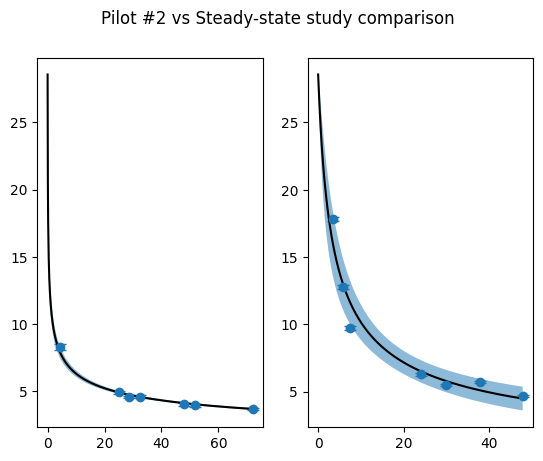

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Pilot #2 vs Steady-state study comparison')

ax1.errorbar(
    t_dataA[:7], y_meanA[:7], yerr=y_semA[:7],
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_dataA, y_meanA, y_semA)
print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, t_dataA[6], 0.1)
y_fitA, y_lower, y_upper = confidence_band(t_fit, optim_res)

print(len(t_fit), len(y_fitA))

ax1.plot(t_fit, y_fitA, 'k-', label='Weighted fit')
ax1.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
# ax1.xlabel('Time')
# ax1.ylabel('Measurement')

ax2.errorbar(
    t_dataB, y_meanB, yerr=y_semB,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_dataB, y_meanB, y_semB)
print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

t_fit = np.arange(0, t_dataB[-1], 0.1)
y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

ax2.plot(t_fit, y_fit, 'k-', label='Weighted fit')
ax2.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
# ax2.xlabel('Time')
# ax2.ylabel('Measurement')
# plt.legend()
# plt.tight_layout()
plt.show()

theta =  [31.51994266 -0.52042644]
a = 32.134
b = -0.547


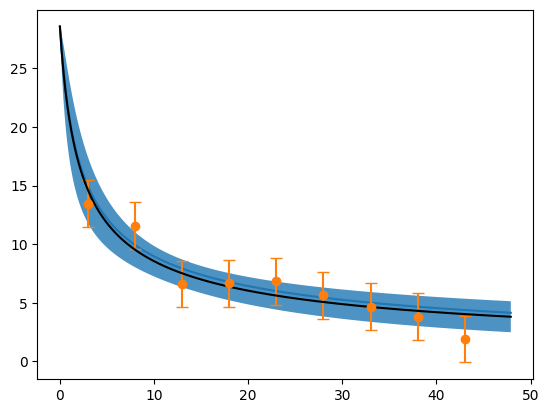

In [72]:
theta = np.random.normal([30, -0.5], [10, 0.1])
print("theta = ", theta)
t_fit = np.arange(0, 48, 0.1)
y = power_law(t_fit, theta) 

plt.plot(t_fit, y)

t_data = np.arange(3, 48, 5)
y_data = power_law(t_data, theta) 
y_data = np.random.normal(y_data, scale=2)

plt.errorbar(t_data, y_data, yerr=2,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_data, y_data, 1)

print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")

y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

plt.plot(t_fit, y_fit, 'k-', label='Weighted fit')
plt.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.8, label='95% confidence band')

plt.show()

a = 31.806
b = -0.526


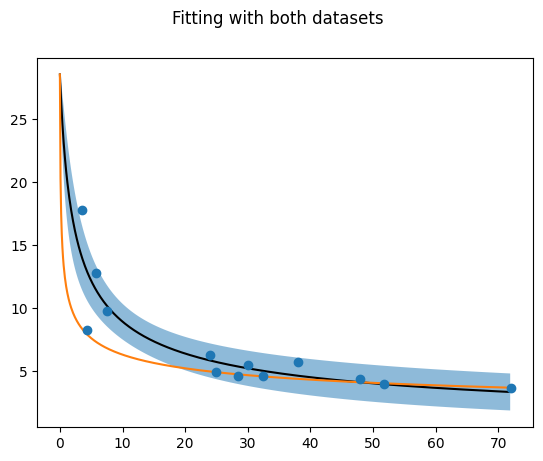

In [ ]:
# time points
t_data = np.array([3.5, 4.25, 5.75, 7.5, 24, 25, 28.5, 30, 32.5, 38, 48, 51.75, 72])

# mean of n samples at each time
y_mean = np.array([17.79526, 8.2668, 12.7622, 9.7465, 6.3022, 4.9254, 4.5688, 5.4894, 4.5752, 5.7354, (4.6958 + 4.0178) / 2, 3.9404, 3.6374])

plt.errorbar(t_data, y_mean,
    fmt='o', capsize=4, label='Data (mean ± SEM)'
)

optim_res = fitting(t_data, y_mean, 1)

print(f"a = {optim_res.x[0]:.3f}")
print(f"b = {optim_res.x[1]:.3f}")


t_fit = np.arange(0, 72, 0.1)

y_fit, y_lower, y_upper = confidence_band(t_fit, optim_res)

plt.plot(t_fit, y_fit, 'k-', label='Weighted fit')

plt.fill_between(t_fit, y_lower, y_upper,
                 alpha=0.5, label='95% confidence band')
plt.suptitle('Fitting with both datasets')

plt.show()

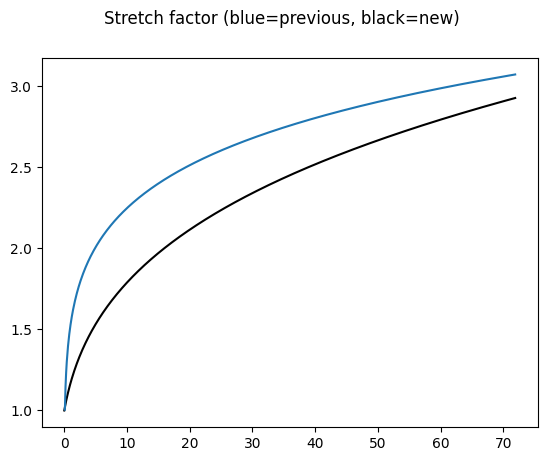

In [18]:
plt.plot(t_fit, 1 / np.sqrt(y_fit / 28.56), 'k-', label='Weighted fit')
plt.plot(t_fit[1:], 1 + (1 / np.sqrt(11.871 * t_fit[1:]**(-0.274) / 22.4696)-1) / 0.71)
plt.suptitle('Stretch factor (blue=previous, black=new)')

plt.show()

In [ ]:
t_0 = (28.56 / 31.8)**(-1/0.5255)
1 / np.sqrt(31.8 * (3.5 + t_0)**(-0.5255) / 28.56)

np.float64(1.425313686898639)

In [112]:
1 + (1 / np.sqrt(11.871 * 3.5**(-0.274) / 22.4696)-1) / 0.71


np.float64(1.8921062608728842)

In [114]:
theta

array([31.80609962, -0.52553111])